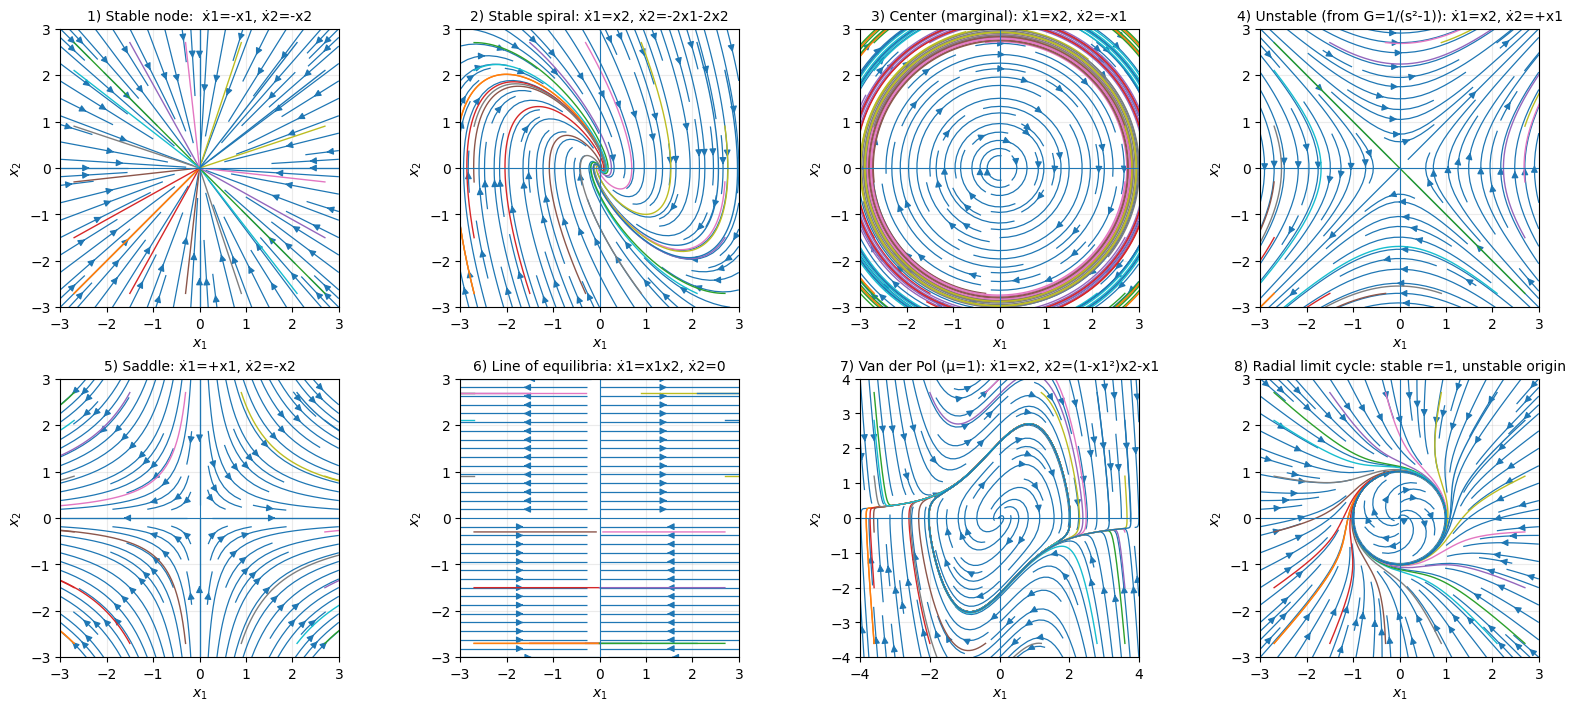

In [ ]:
""" 
This code is generated by AI using the prompt:
"Generate Python code for plotting the phase portraits 
of the following system descriptions:
(all systems were described)
"""
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Phase-portrait helper
# ----------------------------
def phase_portrait(ax, f, g, xlim=(-3, 3), ylim=(-3, 3),
                   grid=33, n_traj=10, tmax=12.0, dt=0.01, title=""):
    x = np.linspace(*xlim, grid)
    y = np.linspace(*ylim, grid)
    X, Y = np.meshgrid(x, y)
    U = f(X, Y)
    V = g(X, Y)

    # Streamplot of vector field
    ax.streamplot(X, Y, U, V, density=1.1, linewidth=0.9, arrowsize=1.0)

    # Simple forward-Euler trajectories from boundary-ish initial conditions
    seeds = []
    xs = np.linspace(xlim[0]*0.9, xlim[1]*0.9, n_traj)
    ys = np.linspace(ylim[0]*0.9, ylim[1]*0.9, n_traj)
    for s in xs[::2]:
        seeds.append((s, ylim[0]*0.9))
        seeds.append((s, ylim[1]*0.9))
    for s in ys[::2]:
        seeds.append((xlim[0]*0.9, s))
        seeds.append((xlim[1]*0.9, s))

    n_steps = int(tmax / dt)
    for x0, y0 in seeds[: max(12, 2*n_traj)]:
        xx, yy = float(x0), float(y0)
        traj_x, traj_y = [xx], [yy]
        for _ in range(n_steps):
            dx = f(xx, yy)
            dy = g(xx, yy)
            # stop if blows up
            if not np.isfinite(dx) or not np.isfinite(dy):
                break
            xx += dt * dx
            yy += dt * dy
            traj_x.append(xx)
            traj_y.append(yy)
            if abs(xx) > 20 or abs(yy) > 20:
                break
        ax.plot(traj_x, traj_y, linewidth=1.0)

    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.axhline(0, linewidth=0.8); ax.axvline(0, linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.grid(True, alpha=0.25)


# ----------------------------
# 8 examples (x1-dot = f(x1,x2), x2-dot = g(x1,x2))
# ----------------------------

# 1) Asymptotically stable node
f1 = lambda x1, x2: -x1
g1 = lambda x1, x2: -x2

# 2) Asymptotically stable spiral (stable focus)
f2 = lambda x1, x2: x2
g2 = lambda x1, x2: -2*x1 - 2*x2

# 3) Marginally stable center (from G(s)=1/(s^2+1))
f3 = lambda x1, x2: x2
g3 = lambda x1, x2: -x1

# 4) Unstable (from G(s)=1/(s^2-1))  <-- this is the unstable transfer-function example
f4 = lambda x1, x2: x2
g4 = lambda x1, x2: x1

# 5) Unstable saddle (separable)
f5 = lambda x1, x2: x1
g5 = lambda x1, x2: -x2

# 6) Non-isolated equilibria / marginal-ish behavior (x2 constant)
f6 = lambda x1, x2: x1*x2
g6 = lambda x1, x2: 0*x1

# 7) Van der Pol (μ=1): stable limit cycle, origin unstable
mu = 1.0
f7 = lambda x1, x2: x2
g7 = lambda x1, x2: mu*(1 - x1**2)*x2 - x1

# 8) Designed radial limit cycle at r=1, origin unstable
f8 = lambda x1, x2: x2 + x1*(1 - x1**2 - x2**2)
g8 = lambda x1, x2: -x1 + x2*(1 - x1**2 - x2**2)


systems = [
    (f1, g1, "1) Stable node:  ẋ1=-x1, ẋ2=-x2", (-3, 3), (-3, 3)),
    (f2, g2, "2) Stable spiral: ẋ1=x2, ẋ2=-2x1-2x2", (-3, 3), (-3, 3)),
    (f3, g3, "3) Center (marginal): ẋ1=x2, ẋ2=-x1", (-3, 3), (-3, 3)),
    (f4, g4, "4) Unstable (from G=1/(s²-1)): ẋ1=x2, ẋ2=+x1", (-3, 3), (-3, 3)),
    (f5, g5, "5) Saddle: ẋ1=+x1, ẋ2=-x2", (-3, 3), (-3, 3)),
    (f6, g6, "6) Line of equilibria: ẋ1=x1x2, ẋ2=0", (-3, 3), (-3, 3)),
    (f7, g7, "7) Van der Pol (μ=1): ẋ1=x2, ẋ2=(1-x1²)x2-x1", (-4, 4), (-4, 4)),
    (f8, g8, "8) Radial limit cycle: stable r=1, unstable origin", (-3, 3), (-3, 3)),
]

# ----------------------------
# Plot all 8
# ----------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True)

for ax, (ff, gg, title, xlim, ylim) in zip(axes.ravel(), systems):
    phase_portrait(ax, ff, gg, xlim=xlim, ylim=ylim, title=title)

plt.savefig("phase_portraits.png", dpi=300)
plt.show()